# LeetCode #784: Letter Case Permutation

https://leetcode.com/problems/letter-case-permutation/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(n \cdot 2^n)$ | $O(n \cdot 2^n)$ |
| **Backtracking (DFS)** | $O(n \cdot 2^n)$ | $O(n)$ |

---

## Understanding the Methods

### Brute Force
Iteratively build the result list, doubling it at each letter by appending both the lower-case and upper-case variants of the current partial string. Scans the list $n$ times — once per character — resulting in $O(n \cdot 2^n)$ total string copies.

### Optimal: Backtracking (DFS) ★
Perform DFS on a shared char array. At each letter, recurse once with the current case, toggle the case with XOR-32, recurse again, then restore — all branches share the same buffer so no extra string copies are needed mid-recursion.

**Why this is better than Brute Force:** Brute Force creates and copies strings $O(2^n)$ times per letter step; DFS holds only one $O(n)$ char array on the stack and clones it only at leaves, giving $O(n)$ auxiliary space instead of $O(n \cdot 2^n)$.

**Constraints:**
* 1 <= s.length <= 12
* s consists of lower-case English letters and digits.

## Solutions

### C#

In [ ]:
public class Solution {
    public IList<string> LetterCasePermutation(string s) {
        var result = new List<string>();
        Backtrack(s.ToCharArray(), 0, result);
        return result;
    }

    private void Backtrack(char[] arr, int i, List<string> result) {
        if (i == arr.Length) { result.Add(new string(arr)); return; }
        // Recurse first with current case to capture the unchanged branch
        Backtrack(arr, i + 1, result);
        if (char.IsLetter(arr[i])) {
            // Toggle case via XOR with 32 (ASCII distance between upper and lower)
            arr[i] ^= (char)32;
            Backtrack(arr, i + 1, result);
            // Restore to leave the shared buffer clean for the caller
            arr[i] ^= (char)32;
        }
    }
}

### Python

In [ ]:
class Solution:
    def letterCasePermutation(self, s: str) -> list[str]:
        result = []
        arr = list(s)

        def backtrack(i: int) -> None:
            if i == len(arr):
                result.append(''.join(arr))
                return
            # Recurse with current case first
            backtrack(i + 1)
            if arr[i].isalpha():
                # Toggle case and recurse the alternate branch
                arr[i] = arr[i].upper() if arr[i].islower() else arr[i].lower()
                backtrack(i + 1)
                # Restore for the caller
                arr[i] = arr[i].upper() if arr[i].islower() else arr[i].lower()

        backtrack(0)
        return result

### Go

In [ ]:
func letterCasePermutation(s string) []string {
    result := []string{}
    arr := []byte(s)
    var backtrack func(i int)
    backtrack = func(i int) {
        if i == len(arr) {
            result = append(result, string(arr))
            return
        }
        // Recurse with current case first
        backtrack(i + 1)
        if arr[i] >= 'a' && arr[i] <= 'z' || arr[i] >= 'A' && arr[i] <= 'Z' {
            // XOR 32 toggles ASCII case bit
            arr[i] ^= 32
            backtrack(i + 1)
            // Restore for the caller
            arr[i] ^= 32
        }
    }
    backtrack(0)
    return result
}

### Rust

In [ ]:
impl Solution {
    pub fn letter_case_permutation(s: String) -> Vec<String> {
        let mut result = Vec::new();
        let mut arr: Vec<u8> = s.into_bytes();
        Self::backtrack(&mut arr, 0, &mut result);
        result
    }

    fn backtrack(arr: &mut Vec<u8>, i: usize, result: &mut Vec<String>) {
        if i == arr.len() {
            result.push(String::from_utf8(arr.clone()).unwrap());
            return;
        }
        // Recurse with current case first
        Self::backtrack(arr, i + 1, result);
        if arr[i].is_ascii_alphabetic() {
            // XOR 32 toggles ASCII case bit
            arr[i] ^= 32;
            Self::backtrack(arr, i + 1, result);
            // Restore for the caller
            arr[i] ^= 32;
        }
    }
}

## Example Scenarios

**1. Common Case**
**Input:** s = "a1b2"
Recursion branches at `i=0` (a/A) and `i=2` (b/B); digits at i=1 and i=3 pass straight through without branching. The DFS tree has $2^2 = 4$ leaves: "a1b2", "a1B2", "A1b2", "A1B2".

**2. Slightly Complex**
**Input:** s = "3z4"
The digit `'3'` at i=0 passes through. The letter `'z'` at i=1 branches: one sub-tree captures "3z4", the other toggles `z^32='Z'` and captures "3Z4". Output: ["3z4", "3Z4"].

**3. Edge Case: Time Factor**
**Input:** s = "abcdefghijkl" (12 letters, all alphabetic)
Every position branches, producing $2^{12} = 4{,}096$ permutations. DFS makes $2^{13}-1 = 8{,}191$ recursive calls total; a BFS approach would process $O(n \cdot 2^n) = 12 \times 4{,}096 = 49{,}152$ string copies, each of length 12.

**4. Edge Case: Space Factor**
**Input:** s = "1234567890" (all digits)
No letter is ever encountered, so the `if isalpha` branch never fires. DFS degenerates to a single straight-line recursion of depth 10, returning exactly ["1234567890"]. Peak auxiliary stack space: $O(n) = 10$ frames.

**5. Almost-Impossible but Plausible**
**Input:** s = "C" (single uppercase letter)
The DFS calls `backtrack(1)` with `arr[0]='C'` — captures "C"; then toggles `'C'^32='c'`, calls `backtrack(1)` — captures "c"; restores `arr[0]` back to `'C'`. The XOR identity ($x \oplus 32 \oplus 32 = x$) guarantees the restore is exact. Output: ["C", "c"].

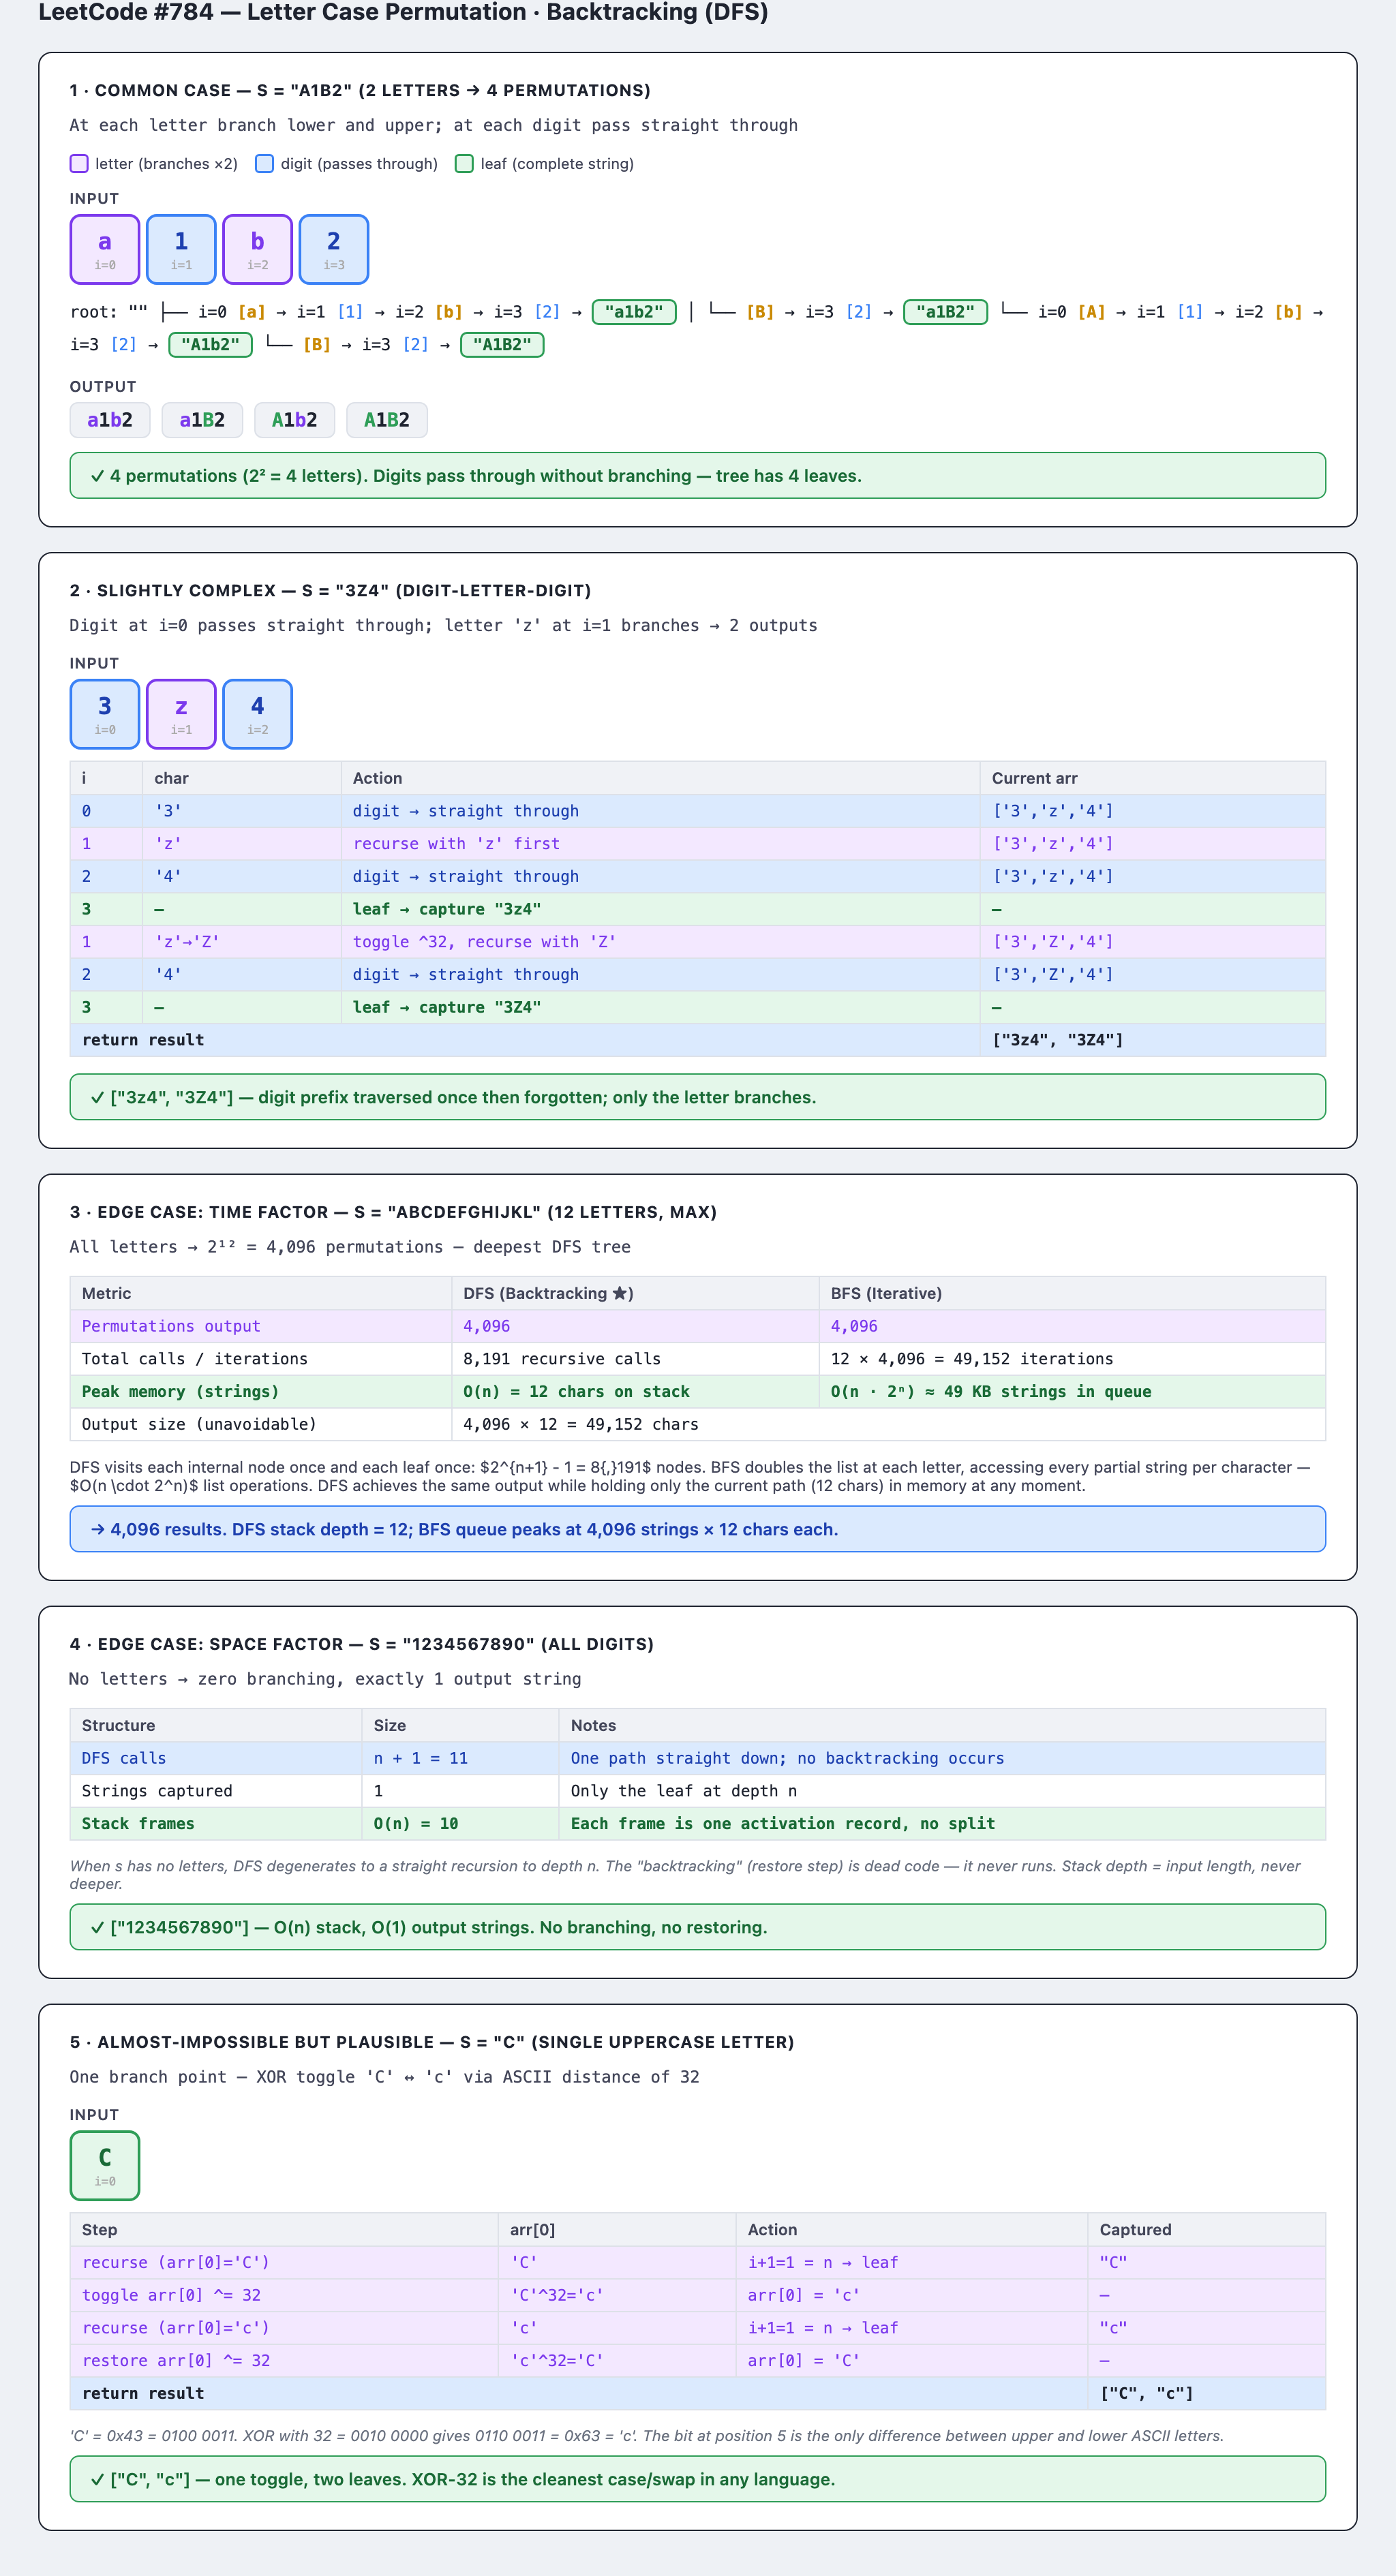